# 4. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [43]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* 2 different classification models, one of which must be **logistic regression**.
* A discussion of which **performance metric** is most relevant for the evaluation of your models.
* 2 different **validation methodologies** used to tune hyperparameters.
* **Confusion matrices** for your models, and associated comments.

## **Data Preperation**

Our data preparation consists of 4 steps:

1. Understanding the dataset
2. Handling missing values
3. Defining our targets
4. Encoding non-numeric values

**Understanding Dataset Structure**

Our dataset has over 60,000 rows and 21 columns. Most of the columns are categorical (object type), which means they can't be used directly in classification models. Also, some columns have a lot of missing values, which makes the dataset harder to use and can cause problems when training a model.

In [44]:
nRow, nCol = df.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 61069 rows and 21 columns


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [46]:
df.isnull().sum().sort_values(ascending=False)

veil-type               57892
spore-print-color       54715
veil-color              53656
stem-root               51538
stem-surface            38124
gill-spacing            25063
cap-surface             14120
gill-attachment          9884
ring-type                2471
cap-color                   0
cap-shape                   0
cap-diameter                0
class                       0
stem-height                 0
stem-width                  0
does-bruise-or-bleed        0
gill-color                  0
has-ring                    0
stem-color                  0
habitat                     0
season                      0
dtype: int64

**Handling Missing Values**

Since a lot of the data was missing in some columns, we cleaned the dataset in two ways.

1. We removed columns that were mostly empty so they would not mess up the model or make it too complicated. - Columns removed had over **50%** of missing values. 

2. For the rest of the missing values, we filled them in with common values (like the most frequent or average) to avoid adding too much fake data.

This made the dataset easier to work with and helped the model learn better.

In [47]:
cols_to_drop = ['veil-type', 'spore-print-color', 'veil-color', 'stem-root', 'stem-surface'] 
df.drop(columns=cols_to_drop, inplace=True)

In [48]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           61069 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       61069 non-null  object 
 7   gill-spacing          61069 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-color            61069 non-null  object 
 12  has-ring              61069 non-null  object 
 13  ring-type             61069 non-null  object 
 14  habitat               61069 non-null  object 
 15  season             

**Define Features and Label**

In [50]:
X = df.drop('class', axis=1)
y = df['class'].map({'e': 0, 'p': 1}) 

**Encode Categorical Variables**

Since we are about to use Logistic Regression and Random Forest Classifier, one-hot encoding will ensure that models can understand and use the data correctly.

In [51]:
X_encoded = pd.get_dummies(X)

## **Classifying Mushrooms**

For this classification task, we chose to use **Logistic Regression** and **Random Forest Classifier**. 

Logistic Regression is a simple and widely-used model that works well for binary classification problems like this one *(edible vs. poisonous mushrooms)*. It also gives interpretable results, which helps in understanding how each feature affects the prediction. 

On the other hand, we picked Random Forest because it is more powerful and can handle complex patterns and interactions between features. It’s also more flexible with noisy data and less affected by outliers. 

Using both models allowed us to compare a basic model with a more advanced one and see which performs better on this dataset.

In [52]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42, test_size=0.2)

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred_log))


Accuracy: 0.7751760275094154


In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_log))

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.75      0.75      5374
           1       0.80      0.80      0.80      6840

    accuracy                           0.78     12214
   macro avg       0.77      0.77      0.77     12214
weighted avg       0.78      0.78      0.78     12214



### Random Forest

In [74]:
from sklearn.ensemble import RandomForestClassifier

rfc_model = RandomForestClassifier(random_state=42, max_depth=6)
rfc_model.fit(X_train,y_train)

y_pred_rfc = rfc_model.predict(X_test)

In [75]:
print("\nAccuracy:", accuracy_score(y_test, y_pred_rfc))


Accuracy: 0.87620763058785


In [76]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rfc))

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      5374
           1       0.88      0.91      0.89      6840

    accuracy                           0.88     12214
   macro avg       0.88      0.87      0.87     12214
weighted avg       0.88      0.88      0.88     12214



### **Performance Metric Discussion**

For this classification task, the most relevant performance metric is the **F1-score**, especially for the poisonous class. This is because predicting a poisonous mushroom as edible (false negative) could be dangerous in real life. The F1-score balances both precision (how many predicted poisonous mushrooms were actually poisonous) and recall (how many actual poisonous mushrooms were correctly identified), making it more reliable than just accuracy. 

While overall accuracy is helpful, it doesn’t tell us enough when the consequences of certain mistakes are more serious than others. As such accuracy is used when the True Positives and True negatives are more important while F1-score is used when the False Negatives and False Positives are crucial.

### **Validation Methodologies**

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

*NOTE: Preparing splits for Train-Validation-Test Methodology*

In [61]:
X_tvt_temp, X_tvt_test, y_tvt_temp, y_tvt_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
X_tvt_train, X_tvt_val, y_tvt_train, y_tvt_val = train_test_split(X_tvt_temp, y_tvt_temp, test_size=0.2, random_state=43)

### Logistic Regression

To tune the hyperparameters of our models, we used two different validation methodologies.

1. We applied a manual **train–validation–test** split, where we split the data into three parts. we trained the model on the training set, tested different values of the regularization parameter C on the validation set, and then used the best version of the model to evaluate on the test set. This approach gave us control over each step and made it easier to understand the effect of different parameters.

2. Was using **GridSearchCV**, which performs automatic hyperparameter tuning using cross-validation. Instead of manually splitting the data into train and validation sets, GridSearchCV tests all parameter combinations (in our case, different C values) using k-fold cross-validation on the training data. It then selects the best model and we evaluated that model on the test set. This method is more thorough and reduces the chances of picking a model that overfits the validation data.

**Manual Train–Validation–Test Split**

In [62]:
best_c = None
best_f1 = 0

for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(X_tvt_train, y_tvt_train)
    y_tvt_val_pred = model.predict(X_tvt_val)
    f1 = f1_score(y_tvt_val, y_tvt_val_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_c = c

X_final_train = pd.concat([X_tvt_train, X_tvt_val])
y_final_train = pd.concat([y_tvt_train, y_tvt_val])
final_model = LogisticRegression(C=best_c, max_iter=1000)
final_model.fit(X_final_train, y_final_train)

y_test_pred = final_model.predict(X_tvt_test)
print(f"\n=== Final Test Set Evaluation for C: {best_c} ===")
print(classification_report(y_tvt_test, y_test_pred))


=== Final Test Set Evaluation for C: 0.1 ===
              precision    recall  f1-score   support

           0       0.74      0.75      0.75      5374
           1       0.80      0.80      0.80      6840

    accuracy                           0.78     12214
   macro avg       0.77      0.77      0.77     12214
weighted avg       0.78      0.78      0.78     12214



**GridSearchCV with Cross-Validation**

In [63]:
param_grid = {'C': [0.01, 0.1, 1, 10]}
grid_model = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, scoring='f1', cv=5)
grid_model.fit(X_train, y_train)

y_logistic_test_pred = grid_model.predict(X_test)
print(f"\n=== Final Test Set Evaluation with best parameters: {grid_model.best_params_} ===")
print(classification_report(y_test, y_logistic_test_pred))


=== Final Test Set Evaluation with best parameters: {'C': 0.1} ===
              precision    recall  f1-score   support

           0       0.74      0.75      0.75      5374
           1       0.80      0.80      0.80      6840

    accuracy                           0.78     12214
   macro avg       0.77      0.77      0.77     12214
weighted avg       0.78      0.78      0.78     12214



### Random Forest

**Manual Train–Validation–Test Split**

In [64]:
param_grid = [
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 200, 'max_depth': 20}
]

best_params = None
best_f1 = 0

for params in param_grid:
    model = RandomForestClassifier(n_estimators=params['n_estimators'],
                                   max_depth=params['max_depth'],
                                   random_state=42)
    model.fit(X_tvt_train, y_tvt_train)
    y_val_pred = model.predict(X_tvt_val)
    score = f1_score(y_tvt_val, y_tvt_val_pred)
    if score > best_f1:
        best_f1 = score
        best_params = params

X_final = pd.concat([X_tvt_train, X_tvt_val])
y_final = pd.concat([y_tvt_train, y_tvt_val])

final_model = RandomForestClassifier(n_estimators=best_params['n_estimators'],
                                     max_depth=best_params['max_depth'],
                                     random_state=42)
final_model.fit(X_final, y_final)

y_test_pred = final_model.predict(X_tvt_test)
print(f"\n=== Final Test Set Evaluation with best parameters: {best_params} ===")
print(classification_report(y_tvt_test, y_test_pred))


=== Final Test Set Evaluation with best parameters: {'n_estimators': 100, 'max_depth': 10} ===
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      5374
           1       0.98      0.98      0.98      6840

    accuracy                           0.98     12214
   macro avg       0.98      0.98      0.98     12214
weighted avg       0.98      0.98      0.98     12214



**GridSearchCV with Cross-Validation**

In [77]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='f1',
                           cv=5,
                           n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_rfc_test_pred = best_model.predict(X_test)

print(f"\n=== Final Test Set Evaluation with best parameters:  {grid_search.best_params_} ===")
print(classification_report(y_test, y_rfc_test_pred))


=== Final Test Set Evaluation with best parameters:  {'max_depth': 20, 'n_estimators': 100} ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5374
           1       1.00      1.00      1.00      6840

    accuracy                           1.00     12214
   macro avg       1.00      1.00      1.00     12214
weighted avg       1.00      1.00      1.00     12214



### **Confusion Matrices and Comments**



**Logistic Regression Confusion Matrix:**

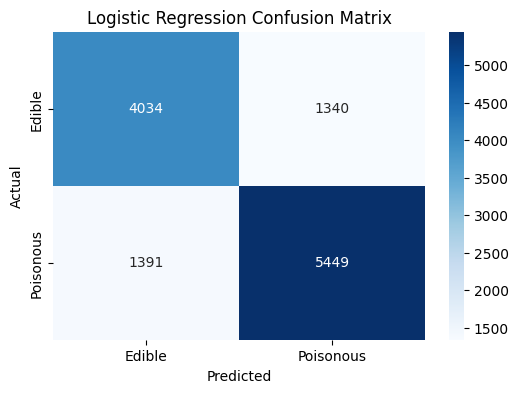

In [70]:
cm = confusion_matrix(y_test, y_logistic_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Edible", "Poisonous"], yticklabels=["Edible", "Poisonous"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- True negatives (Top-Left): Edible mushrooms correctly predicted.
- True positives (Bottom-Right): Poisonous mushrooms correctly predicted.
- False positives (Top-Right): Edible mushrooms wrongly predicted as poisonous.
- False negatives (Bottom-Left): Poisonous mushrooms wrongly predicted as edible.

The model performs okay, but the high number of false negatives is risky.

**Random Forest Confusion Matrix:**

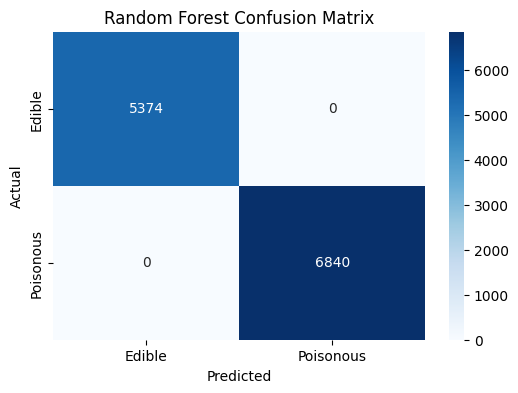

In [78]:
cm = confusion_matrix(y_test, y_rfc_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Edible", "Poisonous"], yticklabels=["Edible", "Poisonous"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Compared to the Logistic Regression the success rate of the Random Forest was perfect after hyperparameter tuning, which resulted in no false positive or false negative classifications. 